# Sweep Results Analysis

Load and analyze backtest permutation sweep results from `MarketSimulator/data/sweep_results/`.

Each row = one backtest run: (trigger signal + params) x (filter signal + params) x (symbol/timeframe).

In [5]:
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

SWEEP_DIR = "../data/sweep_results"

# Load all chunk CSVs across all symbols
csv_files = sorted(glob.glob(f"{SWEEP_DIR}/**/worker_*.csv", recursive=True))
print(f"Found {len(csv_files)} chunk files")

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Total rows: {len(df):,}")
print(f"Symbols: {df['symbol'].unique().tolist()}")
print(f"Timeframes: {df['timeframe'].unique().tolist()}")
print(f"Status breakdown:\n{df['status'].value_counts().to_string()}")
print(f"\nTrigger signals: {df['trigger_name'].nunique()}")
print(f"Filter signals:  {df['filter_name'].nunique()}")

# Symbol-to-timeframe mapping
print("\nSymbol -> Timeframe:")
print(df.groupby("symbol")["timeframe"].first().to_string())

Found 92 chunk files
Total rows: 92,496
Symbols: ['BTC', 'DOGE', 'ETH', 'LINK', 'PAXG', 'SOL']
Timeframes: ['1d', '5m', '4h', '30m', '1h']
Status breakdown:
status
no_trades    67274
ok           25222

Trigger signals: 24
Filter signals:  62

Symbol -> Timeframe:
symbol
BTC      1d
DOGE     5m
ETH      4h
LINK    30m
PAXG     1h
SOL      5m


## Filter to valid runs

Drop errors and zero-trade runs for the analysis queries. Keep the raw `df` around for error-rate analysis if needed.

In [6]:
# Runs that actually traded
valid = df[df["status"] == "ok"].copy()
print(f"Valid runs (status=ok, trades>0): {len(valid):,} / {len(df):,} ({len(valid)/len(df)*100:.1f}%)")
print(f"Error runs: {(df['status']=='error').sum():,}")
print(f"No-trade runs: {(df['status']=='no_trades').sum():,}")

# Per-symbol valid counts
print("\nValid runs per symbol:")
print(valid.groupby("symbol").size().to_string())

Valid runs (status=ok, trades>0): 25,222 / 92,496 (27.3%)
Error runs: 0
No-trade runs: 67,274

Valid runs per symbol:
symbol
BTC     9891
DOGE    1127
ETH     1397
LINK    3092
PAXG    4497
SOL     5218


## Top strategies by metric

Reusable query function. Pass any metric column and optional filters.

In [15]:
DISPLAY_COLS = [
    "symbol", "timeframe", "trigger_name", "trigger_params", "filter_name", "filter_params",
    "total_trades", "win_rate", "annual_return", "sharpe_ratio", "sortino_ratio",
    "max_drawdown", "calmar_ratio", "net_pnl", "ending_balance",
]

def top_strategies(
    metric: str,
    n: int = 20,
    ascending: bool = False,
    symbol: str = None,
    timeframe: str = None,
    min_trades: int = 0,
    min_win_rate: float = 0.0,
    trigger: str = None,
    filter_signal: str = None,
    data: pd.DataFrame = None,
) -> pd.DataFrame:
    """Query top strategies by any metric column.

    Args:
        metric: Column to sort by (e.g. 'sharpe_ratio', 'total_trades', 'annual_return').
        n: Number of results to return.
        ascending: Sort ascending (True) or descending (False).
        symbol: Filter to a specific symbol (e.g. 'BTC').
        timeframe: Filter to a specific timeframe (e.g. '1d', '4h', '5m').
        min_trades: Minimum total_trades threshold.
        min_win_rate: Minimum win_rate threshold (0-1 scale).
        trigger: Filter to a specific trigger signal name.
        filter_signal: Filter to a specific filter signal name.
        data: DataFrame to query (defaults to `valid`).
    """
    result = data if data is not None else valid
    if symbol:
        result = result[result["symbol"] == symbol.upper()]
    if timeframe:
        result = result[result["timeframe"] == timeframe.lower()]
    if min_trades > 0:
        result = result[result["total_trades"] >= min_trades]
    if min_win_rate > 0:
        result = result[result["win_rate"] >= min_win_rate]
    if trigger:
        result = result[result["trigger_name"] == trigger]
    if filter_signal:
        result = result[result["filter_name"] == filter_signal]

    cols = DISPLAY_COLS if metric in DISPLAY_COLS else DISPLAY_COLS + [metric]
    return result.nsmallest(n, metric)[cols] if ascending else result.nlargest(n, metric)[cols]

### Highest trade frequency

In [14]:
top_strategies("total_trades")

,symbol,timeframe,trigger_name,trigger_params,filter_name,filter_params,total_trades,win_rate,annual_return,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,net_pnl,ending_balance
40143,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",cmf_bearish,"{""window"": 46, ""threshold"": 0.5789}",2906,0.2911,26.6614,1.1813,2.2444,18.0360,1.4782,9071.0000,19071.0030
40106,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",ao_bearish,"{""window_fast"": 6, ""window_slow"": 45, ""thresho...",2905,0.2916,27.2923,1.2044,2.3045,17.9607,1.5196,9331.6000,19331.6034
40267,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",roc_negative,"{""window"": 42, ""threshold"": 4}",2807,0.2928,25.0293,1.1222,2.3471,17.4691,1.4328,8407.2300,18407.2332
40273,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",roc_positive,"{""window"": 50, ""threshold"": -5}",2799,0.2862,23.5464,1.0391,2.1980,21.9815,1.0712,7816.9900,17816.9852
40108,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",ao_bearish,"{""window_fast"": 8, ""window_slow"": 35, ""thresho...",2776,0.2947,24.6198,1.1481,2.0414,18.7799,1.3110,8243.0100,18243.0058
40266,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",roc_negative,"{""window"": 37, ""threshold"": 4}",2741,0.2981,25.2741,1.1134,2.3529,18.0489,1.4003,8505.8400,18505.8412
40177,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",dpo_positive,"{""window"": 42}",2362,0.3019,27.4510,1.2984,2.5459,16.3718,1.6767,9397.5200,19397.5215
40173,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",dpo_negative,"{""window"": 37}",2334,0.2862,20.5041,1.0002,2.0156,18.3347,1.1183,6643.9800,16643.9828
40178,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",dpo_positive,"{""window"": 46}",2332,0.3062,28.7226,1.3352,2.7436,14.6831,1.9562,9930.7100,19930.7059
40243,DOGE,5m,mass_reversal_signal,"{""window_fast"": 6, ""window_slow"": 26, ""thresho...",obv_bearish,"{""window"": 45}",2271,0.3007,25.6516,1.1465,2.2392,15.1115,1.6975,8658.5400,18658.5412


### Highest annual return (min 10 trades)

In [16]:
top_strategies("annual_return", min_trades=10)

,symbol,timeframe,trigger_name,trigger_params,filter_name,filter_params,total_trades,win_rate,annual_return,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,net_pnl,ending_balance
35166,BTC,1d,pvo_bullish_cross,"{""window_slow"": 28, ""window_fast"": 20, ""window...",nvi_bearish,"{""window"": 121}",35,0.6857,226.7376,4.4489,5.5692,7.6751,29.5421,3416.5900,13416.5933
35788,BTC,1d,pvo_bullish_cross,"{""window_slow"": 44, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 437}",17,0.9412,222.8431,5.2682,0.0000,1.1312,196.9900,3357.9100,13357.9091
35476,BTC,1d,pvo_bullish_cross,"{""window_slow"": 35, ""window_fast"": 6, ""window_...",nvi_bearish,"{""window"": 184}",40,0.6500,218.4057,4.2813,3.1655,14.0184,15.5800,3291.0500,13291.0455
34236,BTC,1d,pvo_bearish_cross,"{""window_slow"": 33, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 142}",42,0.6190,215.4908,4.3723,5.2779,11.6118,18.5580,3247.1200,13247.1213
34546,BTC,1d,pvo_bearish_cross,"{""window_slow"": 46, ""window_fast"": 9, ""window_...",nvi_bearish,"{""window"": 142}",34,0.7059,209.9212,4.2095,5.3180,10.0922,20.8003,3163.2000,13163.1962
35475,BTC,1d,pvo_bullish_cross,"{""window_slow"": 35, ""window_fast"": 6, ""window_...",nvi_bearish,"{""window"": 255}",36,0.6944,209.3453,4.4657,6.9374,7.4046,28.2724,3154.5200,13154.5188
35785,BTC,1d,pvo_bullish_cross,"{""window_slow"": 44, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 255}",26,0.7308,205.1176,4.6727,8.3427,3.8169,53.7395,3090.8100,13090.8130
35787,BTC,1d,pvo_bullish_cross,"{""window_slow"": 44, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 247}",26,0.7308,204.8954,4.6665,11.0215,3.1521,65.0021,3087.4600,13087.4648
35167,BTC,1d,pvo_bullish_cross,"{""window_slow"": 28, ""window_fast"": 20, ""window...",nvi_bearish,"{""window"": 142}",34,0.6765,202.3224,3.9951,5.2134,9.5801,21.1190,3048.6900,13048.6932
34235,BTC,1d,pvo_bearish_cross,"{""window_slow"": 33, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 255}",28,0.6786,198.1027,5.1851,6.3115,5.3942,36.7253,2985.1100,12985.1086


### Best Sharpe ratio (min 10 trades)

In [9]:
top_strategies("sharpe_ratio", min_trades=10)

,symbol,timeframe,trigger_name,trigger_params,filter_name,filter_params,total_trades,win_rate,annual_return,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,net_pnl,ending_balance
34239,BTC,1d,pvo_bearish_cross,"{""window_slow"": 33, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 437}",17,0.8235,184.1868,5.8910,0.0000,0.5101,361.0617,2775.4200,12775.4170
33308,BTC,1d,pvo_bearish_cross,"{""window_slow"": 26, ""window_fast"": 12, ""window...",nvi_bearish,"{""window"": 247}",18,0.8333,175.3203,5.8660,5.3408,2.3152,75.7248,2641.8100,12641.8121
33305,BTC,1d,pvo_bearish_cross,"{""window_slow"": 26, ""window_fast"": 12, ""window...",nvi_bearish,"{""window"": 255}",19,0.8421,187.3249,5.8543,5.6734,2.3152,80.9099,2822.7000,12822.7041
33617,BTC,1d,pvo_bearish_cross,"{""window_slow"": 24, ""window_fast"": 18, ""window...",nvi_bearish,"{""window"": 247}",18,0.8333,179.3153,5.8145,5.4539,2.3152,77.4504,2702.0100,12702.0121
33615,BTC,1d,pvo_bearish_cross,"{""window_slow"": 24, ""window_fast"": 18, ""window...",nvi_bearish,"{""window"": 255}",19,0.8421,191.3255,5.7713,5.7873,2.3152,82.6378,2882.9900,12882.9863
35788,BTC,1d,pvo_bullish_cross,"{""window_slow"": 44, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 437}",17,0.9412,222.8431,5.2682,0.0000,1.1312,196.9900,3357.9100,13357.9091
30516,BTC,1d,ppo_bearish_cross,"{""window_slow"": 21, ""window_fast"": 5, ""window_...",nvi_bearish,"{""window"": 100}",19,0.6316,134.6778,5.2504,12.8195,2.4472,55.0338,2029.3900,12029.3909
3152,BTC,1d,kama_cross_down,"{""window"": 10, ""pow1"": 4, ""pow2"": 30}",roc_negative,"{""window"": 40, ""threshold"": -3}",13,0.6154,101.1804,5.2036,8.6766,2.1765,46.4873,1524.6400,11524.6368
34235,BTC,1d,pvo_bearish_cross,"{""window_slow"": 33, ""window_fast"": 7, ""window_...",nvi_bearish,"{""window"": 255}",28,0.6786,198.1027,5.1851,6.3115,5.3942,36.7253,2985.1100,12985.1086
34545,BTC,1d,pvo_bearish_cross,"{""window_slow"": 46, ""window_fast"": 9, ""window_...",nvi_bearish,"{""window"": 255}",21,0.8095,188.1417,5.1335,7.3419,2.5771,73.0043,2835.0100,12835.0112


### Best by asset -- BTC highest return, min 10 trades, >50% win rate

In [ ]:
top_strategies("annual_return", symbol="BTC", min_trades=10, min_win_rate=0.50)

### Lowest max drawdown (min 10 trades, positive return)

In [ ]:
profitable = valid[valid["annual_return"] > 0]
top_strategies("max_drawdown", ascending=True, min_trades=10, data=profitable)

## Signal leaderboards

Which trigger and filter signals appear most often in the top N strategies?

In [ ]:
def signal_leaderboard(metric: str, top_n: int = 500, min_trades: int = 5):
    """Which signals appear most often in the top N strategies by a given metric?"""
    pool = valid[valid["total_trades"] >= min_trades].nlargest(top_n, metric)

    trigger_counts = pool["trigger_name"].value_counts().head(15)
    filter_counts = pool["filter_name"].value_counts().head(15)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Signals most represented in top {top_n} by {metric} (min {min_trades} trades)", fontsize=13)

    trigger_counts.plot.barh(ax=ax1, color="#2196F3")
    ax1.set_title("Trigger signals")
    ax1.set_xlabel("Count")
    ax1.invert_yaxis()

    filter_counts.plot.barh(ax=ax2, color="#FF9800")
    ax2.set_title("Filter signals")
    ax2.set_xlabel("Count")
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()

signal_leaderboard("sharpe_ratio", top_n=500, min_trades=10)

In [ ]:
signal_leaderboard("annual_return", top_n=500, min_trades=10)

## Per-symbol metric distributions

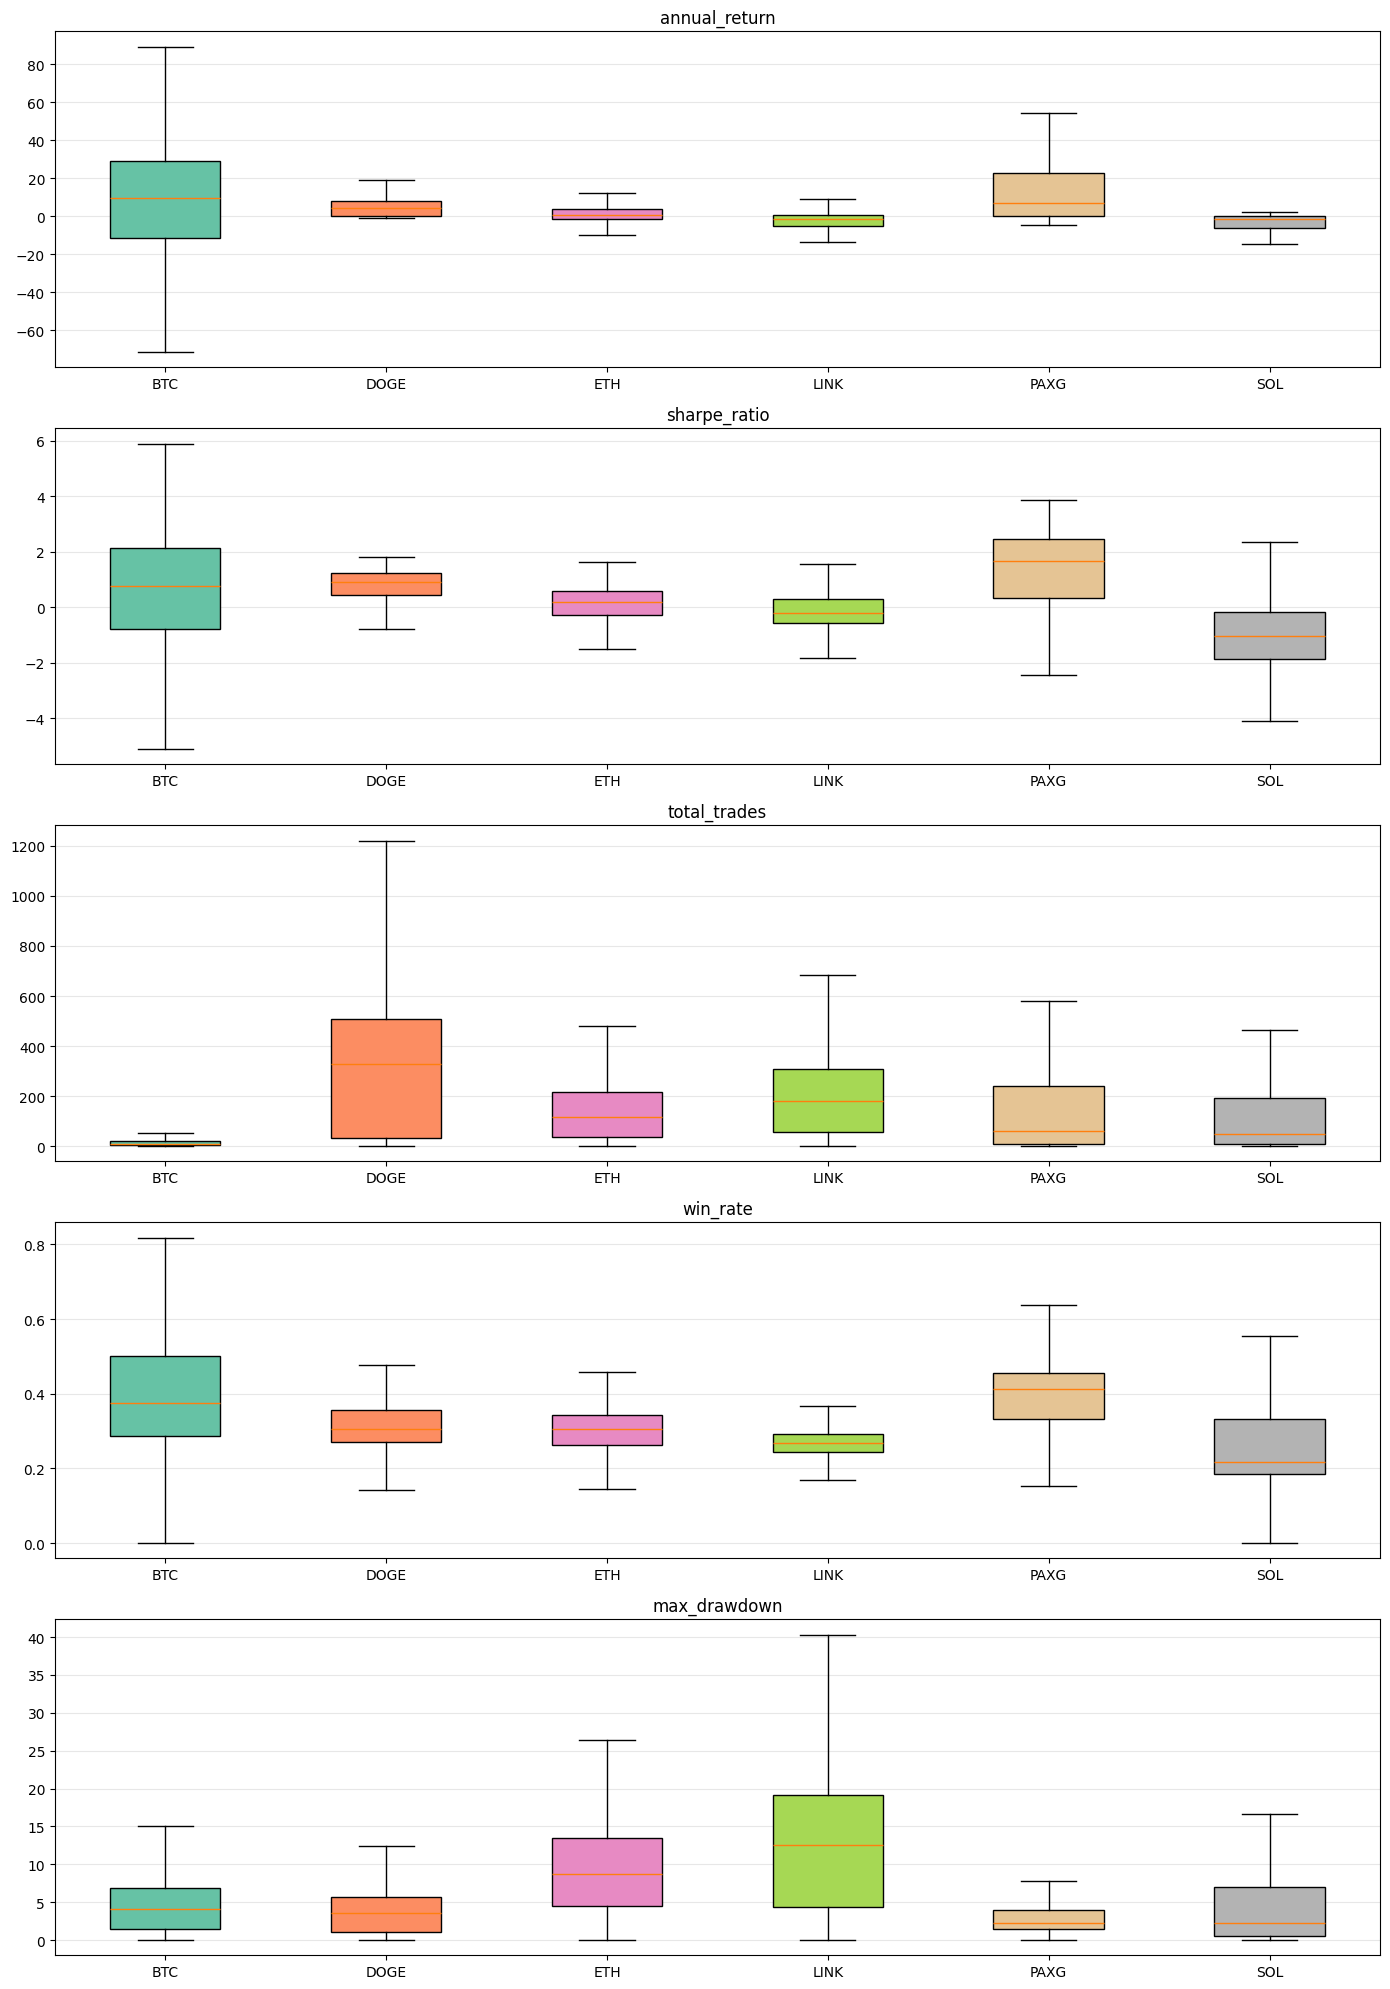

In [17]:
metrics_to_plot = ["annual_return", "sharpe_ratio", "total_trades", "win_rate", "max_drawdown"]
symbols = sorted(valid["symbol"].unique())

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(14, 4 * len(metrics_to_plot)))

for ax, metric in zip(axes, metrics_to_plot):
    data_by_sym = [valid[valid["symbol"] == s][metric].dropna() for s in symbols]
    bp = ax.boxplot(data_by_sym, labels=symbols, vert=True, patch_artist=True, showfliers=False)
    colors = plt.cm.Set2(np.linspace(0, 1, len(symbols)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Trigger x Filter heatmap

Average metric across all param combos for each trigger/filter pair.

In [ ]:
def signal_heatmap(metric: str, symbol: str = None, min_trades: int = 5, cmap: str = "RdYlGn"):
    """Heatmap of avg metric for each trigger x filter combination."""
    pool = valid[valid["total_trades"] >= min_trades]
    if symbol:
        pool = pool[pool["symbol"] == symbol.upper()]

    pivot = pool.pivot_table(
        values=metric, index="trigger_name", columns="filter_name", aggfunc="mean"
    )
    # Drop rows/cols with all NaN
    pivot = pivot.dropna(axis=0, how="all").dropna(axis=1, how="all")

    fig, ax = plt.subplots(figsize=(max(14, len(pivot.columns) * 0.6), max(6, len(pivot) * 0.4)))
    title = f"Mean {metric} by trigger x filter"
    if symbol:
        title += f" ({symbol})"
    title += f" (min {min_trades} trades)"

    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

signal_heatmap("sharpe_ratio", min_trades=10)

In [ ]:
signal_heatmap("sharpe_ratio", symbol="BTC", min_trades=10)

## Error analysis

Which signals error most often? Useful for finding broken signal implementations.

In [ ]:
errors = df[df["status"] == "error"]
if len(errors) > 0:
    print(f"Total errors: {len(errors):,} ({len(errors)/len(df)*100:.1f}%)\n")

    print("Errors by trigger signal:")
    print(errors["trigger_name"].value_counts().head(10).to_string())
    print(f"\nErrors by filter signal:")
    print(errors["filter_name"].value_counts().head(10).to_string())
    print(f"\nTop error messages:")
    print(errors["error_msg"].value_counts().head(10).to_string())
else:
    print("No errors found.")

## Summary statistics per symbol

In [ ]:
summary = valid.groupby("symbol").agg(
    runs=("run_id", "count"),
    median_trades=("total_trades", "median"),
    mean_trades=("total_trades", "mean"),
    median_win_rate=("win_rate", "median"),
    median_return=("annual_return", "median"),
    p90_return=("annual_return", lambda x: x.quantile(0.90)),
    p99_return=("annual_return", lambda x: x.quantile(0.99)),
    median_sharpe=("sharpe_ratio", "median"),
    p90_sharpe=("sharpe_ratio", lambda x: x.quantile(0.90)),
    median_drawdown=("max_drawdown", "median"),
    mean_pnl=("net_pnl", "mean"),
    profitable_pct=("net_pnl", lambda x: (x > 0).mean()),
).round(4)

summary

## Trades and returns by timeframe

In [ ]:
# Order timeframes from shortest to longest
TF_ORDER = ["5m", "15m", "30m", "1h", "4h", "1d"]
valid["tf_sort"] = pd.Categorical(valid["timeframe"], categories=TF_ORDER, ordered=True)

tf_summary = valid.groupby("timeframe").agg(
    symbol=("symbol", "first"),
    runs=("run_id", "count"),
    median_trades=("total_trades", "median"),
    mean_trades=("total_trades", "mean"),
    max_trades=("total_trades", "max"),
    median_return=("annual_return", "median"),
    mean_return=("annual_return", "mean"),
    p90_return=("annual_return", lambda x: x.quantile(0.90)),
    median_sharpe=("sharpe_ratio", "median"),
    mean_sharpe=("sharpe_ratio", "mean"),
    profitable_pct=("net_pnl", lambda x: (x > 0).mean()),
).round(4)

tf_summary = tf_summary.reindex([tf for tf in TF_ORDER if tf in tf_summary.index])
tf_summary

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Trades by timeframe
tf_grouped = valid.sort_values("tf_sort")
tfs_present = [tf for tf in TF_ORDER if tf in valid["timeframe"].values]

# 1. Trade count distribution by timeframe
data_trades = [valid[valid["timeframe"] == tf]["total_trades"].dropna() for tf in tfs_present]
bp1 = axes[0, 0].boxplot(data_trades, labels=tfs_present, patch_artist=True, showfliers=False)
for patch, c in zip(bp1["boxes"], plt.cm.viridis(np.linspace(0.2, 0.8, len(tfs_present)))):
    patch.set_facecolor(c)
axes[0, 0].set_title("Trade count by timeframe")
axes[0, 0].set_ylabel("Total trades")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Annual return distribution by timeframe
data_ret = [valid[valid["timeframe"] == tf]["annual_return"].dropna() for tf in tfs_present]
bp2 = axes[0, 1].boxplot(data_ret, labels=tfs_present, patch_artist=True, showfliers=False)
for patch, c in zip(bp2["boxes"], plt.cm.viridis(np.linspace(0.2, 0.8, len(tfs_present)))):
    patch.set_facecolor(c)
axes[0, 1].set_title("Annual return by timeframe")
axes[0, 1].set_ylabel("Annual return (%)")
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. Mean trades per timeframe (bar)
mean_trades = valid.groupby("timeframe")["total_trades"].mean().reindex(tfs_present)
bars = axes[1, 0].bar(tfs_present, mean_trades.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(tfs_present))))
axes[1, 0].set_title("Mean trade count by timeframe")
axes[1, 0].set_ylabel("Mean trades")
axes[1, 0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, mean_trades.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.0f}", ha="center", fontsize=9)

# 4. Sharpe distribution by timeframe
data_sharpe = [valid[valid["timeframe"] == tf]["sharpe_ratio"].dropna() for tf in tfs_present]
bp4 = axes[1, 1].boxplot(data_sharpe, labels=tfs_present, patch_artist=True, showfliers=False)
for patch, c in zip(bp4["boxes"], plt.cm.viridis(np.linspace(0.2, 0.8, len(tfs_present)))):
    patch.set_facecolor(c)
axes[1, 1].set_title("Sharpe ratio by timeframe")
axes[1, 1].set_ylabel("Sharpe ratio")
axes[1, 1].grid(axis="y", alpha=0.3)

plt.suptitle("Performance by strategy timeframe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Custom queries

Use `top_strategies()` with any combination of filters. Examples:

```python
# SOL strategies with best Sortino, at least 20 trades
top_strategies("sortino_ratio", symbol="SOL", min_trades=20)

# Best Sharpe on 5-minute timeframe
top_strategies("sharpe_ratio", timeframe="5m", min_trades=20)

# Best return on daily timeframe, >50% win rate
top_strategies("annual_return", timeframe="1d", min_trades=10, min_win_rate=0.50)

# Best Calmar ratio for a specific trigger
top_strategies("calmar_ratio", trigger="macd_bullish_cross", min_trades=10)

# Strategies using a specific filter with >60% win rate
top_strategies("annual_return", filter_signal="rsi_oversold", min_win_rate=0.60)

# Heatmap for a specific symbol
signal_heatmap("annual_return", symbol="ETH", min_trades=10)
```

In [ ]:
# -- Your queries here --
